In [3]:
import Pkg

Pkg.instantiate()

using Pkg

cd(@__DIR__)
Pkg.activate("../")
Pkg.add(url="https://github.com/tp2750/TuningSystems.jl") 
Pkg.add("Plots")

Pkg.add("DSP")
using DSP
using Dates, SonifSismo, CairoMakie
using Statistics
using WAV
using Seis
using DSP: conv
using TuningSystems
using Test
using Plots

archive = DataArchive("C:/Users/lucie/Desktop/mtFujiContinuous/mtFujiContinuous")
push!(LOAD_PATH, "C:/Users/lucie/Desktop/TuningSystems.jl-main/TuningSystems.jl-main/src")
include("C:/Users/lucie/Desktop/sonifSismo.jl-main/examples/sonify_one_trace.jl")

  Activating project at `c:\Users\lucie\Desktop\sonifSismo.jl-main`
    Updating git-repo `https://github.com/tp2750/TuningSystems.jl`
    Updating registry at `C:\Users\lucie\.julia\registries\General.toml`
   Resolving package versions...
      Compat entries added for 
     Project No packages added to or removed from `C:\Users\lucie\Desktop\sonifSismo.jl-main\Project.toml`
    Manifest No packages added to or removed from `C:\Users\lucie\Desktop\sonifSismo.jl-main\Manifest.toml`
   Resolving package versions...
      Compat entries added for 
     Project No packages added to or removed from `C:\Users\lucie\Desktop\sonifSismo.jl-main\Project.toml`
    Manifest No packages added to or removed from `C:\Users\lucie\Desktop\sonifSismo.jl-main\Manifest.toml`
   Resolving package versions...
      Compat entries added for 
     Project No packages added to or removed from `C:\Users\lucie\Desktop\sonifSismo.jl-main\Project.toml`
    Manifest No packages added to or removed from `C:\Users\

false

In [4]:
archive = DataArchive("C:/Users/lucie/Desktop/mtFujiContinuous/mtFujiContinuous")

available_stations(archive)
available_channels(archive)

33-element Vector{ChannelAvailability}:
 ChannelAvailability("EV", "FJO", "", "E", [Date("2008-05-25"), Date("2008-05-26"), Date("2008-05-27"), Date("2008-05-28"), Date("2008-05-29"), Date("2008-05-30"), Date("2008-05-31")], ["C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\25\\EV.FJO..E.20080525.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\26\\EV.FJO..E.20080526.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\27\\EV.FJO..E.20080527.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\28\\EV.FJO..E.20080528.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\29\\EV.FJO..E.20080529.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\30\\EV.FJO..E.20080530.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\31\\EV.FJO..E.2008053

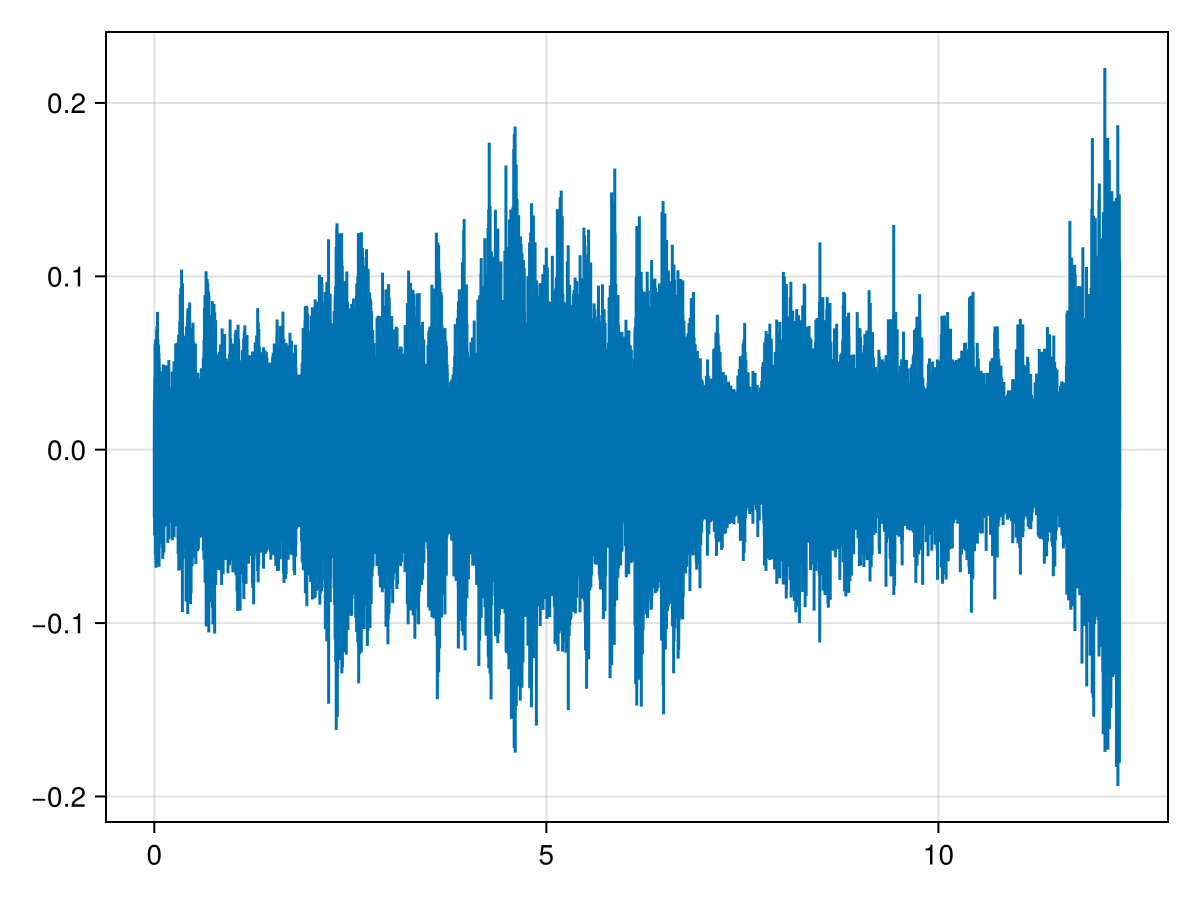

In [55]:
# Enregistrement musique Taylor Swift

using WAV
using Plots

# Charger le fichier audio
y, fs = wavread("C:/Users/lucie/Desktop/Sonification/Tchaikovsky_cut.wav")

# Si stéréo, prendre un seul canal
if ndims(y) > 1
    y = y[:, 1]
end

# Axe temporel
t = (0:length(y)-1) / fs

# Tracé
graphe = lines(t,y)

In [56]:
save("C:/Users/lucie/Desktop/Sonification/TS_cut.png", graphe)

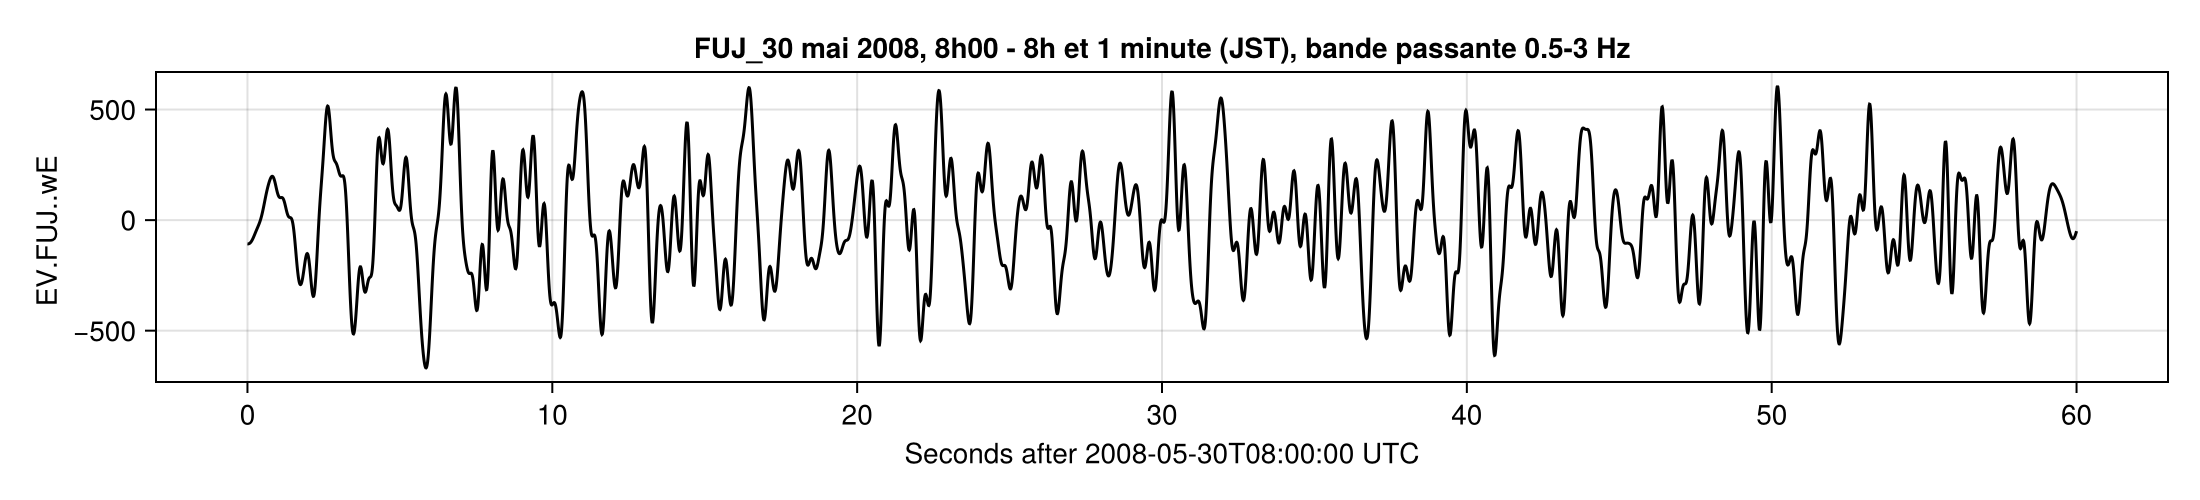

In [53]:
start_time = DateTime(2008, 5, 30, 8, 0, 0)  # UTC
end_time   = DateTime(2008, 5, 30, 8, 1, 0)     # UTC

# TEST 1 - de 0,5 à 3 Hz

traces = read_window(
    archive,
    start_time,
    end_time;
    stations="FUJ",
    channels="wE",
    merge=true,
    processed=true,
    bandpass=(0.5, 3),
)

# Graphe
plot_events = read_catalog(      # Lire les événements pour la période spécifiée
    archive;
    start=start_time,
    stop=end_time,
)

wavefig = plot_waveforms(        # Afficher les formes d'ondes des traces
    traces;
    events=plot_events,
    title="FUJ_30 mai 2008, 8h00 - 8h et 1 minute (JST), bande passante 0.5-3 Hz",
)
wavefig

In [54]:
save("C:/Users/lucie/Desktop/Sonification/Séisme_conv.png", wavefig)

In [80]:
son = sonify_trace(traces[1]; acceleration=3000, level=0.9, gain=2, saturation=:soft)

(signal = [-3.330379937580191e-5, -0.0007970321669020669, -0.001404596489088893, -0.001678819532017271, -0.0015706703398218553, -0.0011478198812167875, -0.00032569168301812326, 0.0013004947063336304, 0.004046065503723562, 0.007605411826074164  …  0.008558068064079435, 0.006511302686530743, 0.004468075396498825, 0.0023660038081082416, 0.00046958302714632195, -0.0008674157951779228, -0.0014336261756797823, -0.0012382978063100593, -0.0005924086675277804, -3.330379937580191e-5], sample_rate = 44100, playback_factor = 3000.0, seismic_duration = 60.01, audio_duration = 0.02)

In [81]:
Convo = conv(son[1], y)

591893-element Vector{Float64}:
 -1.981945517842698e-7
 -4.898732073418954e-6
 -1.2178087760550405e-5
 -1.8894656135526322e-5
 -2.144193870502742e-5
 -1.682251228006526e-5
 -2.1329978078625522e-6
  2.6983209451405393e-5
  7.510230221840358e-5
  0.00014204992888432535
  ⋮
 -0.00038477631978621474
 -0.00016268490115246836
  1.7192876180516237e-6
  9.885357344391332e-5
  0.0001294800759794948
  0.00010926125293233419
  6.414143258950261e-5
  2.2090744285746533e-5
  1.181036252399792e-6

In [82]:
wavwrite(Float32.(Convo), "convolution.wav")